In [1]:
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import time

In [2]:
load_dotenv()
llm = ChatOpenAI()


In [3]:
class JokeState(TypedDict):
    topic : str
    joke: str
    explanation: str

In [4]:
def generate_joke(state:JokeState):
    prompt = f'generate a joke on the topic -{state["topic"]}'
    response = llm.invoke(prompt).content
    return {'joke', response} 

In [5]:
def generate_explanation(state: JokeState):
    prompt = f'write explanation for the joke -{state["joke"]}'
    response = llm.invoke(prompt).content
    return {'explanation', response}

In [6]:
graph = StateGraph(JokeState)

# add nodes

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

# add edges

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

# add checkpoint

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

In [7]:
config1 = {"configurable":{"thread_id": "1"}}
workflow.invoke({'topic': 'pizza'},config=config1)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [8]:
#final state values fetched
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-24T06:01:11.261419+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-2896-659d-bfff-6edf46d79854'}}, tasks=(PregelTask(id='3d8192d5-bac3-b5d6-4498-8bc5e4f88d3c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=())

In [9]:
# all intermediate values fetched
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-24T06:01:11.261419+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-2896-659d-bfff-6edf46d79854'}}, tasks=(PregelTask(id='3d8192d5-bac3-b5d6-4498-8bc5e4f88d3c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={}, next=('__start_

In [9]:
config2 = {"configurable":{"thread_id": "2"}}
workflow.invoke({'topic': 'pasta'},config=config2)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [10]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfe53-0f6f-67fc-8000-92072f7e9975'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-23T09:53:11.048191+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfe53-0f6b-6a66-bfff-1b3a47ddba92'}}, tasks=(PregelTask(id='fd517a3a-c255-ec93-cb22-346b46f9cd5f', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={}, next=('__start_

**Persistence Benefits** 

    pesistence gives 4 benefits:
    
      * short term memory (purana kaam dobara resume hojata hai memory save hojati hai isliye)
      * fault tolerance (kissi bhi state par crash hojai dobara resume nahi hoga wahi se start hoga kaam)
      * HITL (Human in the loop)
      * Time Travel


**Fault Tolerance Test**

       30 secs delay added at step 2 then interupt with any keyboard key crash happens then start again so it starts from where the crash happens not from beginning

In [29]:
# Define state for crash recovery example
class crashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [30]:
# Define steps
def step1(state: crashState) -> crashState:
    print("step1 executed") 
    return {"step1":"done","input": state["input"]}        
def step2(state: crashState) -> crashState:        
    print("step2 hanging ... now manually terminate the program to simulate crash")    
    time.sleep(30)
    return {"step2": "done"}
def step3(state: crashState) -> crashState:
    print("step3 executed") 
    return {"step3":"done"}

In [31]:
# build the graph
builder = StateGraph(crashState)
builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

# add edges
builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")      
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


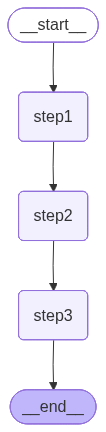

In [32]:
graph

In [ ]:
try:
    print("Running graph, please manually interupt during step2 to simulate crash")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("Simulated crash occurred!")

Running graph, please manually interupt during step2 to simulate crash
step1 executed
step2 hanging ... now manually terminate the program to simulate crash
Simulated crash occurred!


In [34]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58af-6f7d-8001-f96ebfce618a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-12-23T10:28:39.369305+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58aa-659a-8000-80aba8ce9fca'}}, tasks=(PregelTask(id='1c1524b8-1235-abcc-763d-ea3acac86661', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [35]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58af-6f7d-8001-f96ebfce618a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-12-23T10:28:39.369305+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58aa-659a-8000-80aba8ce9fca'}}, tasks=(PregelTask(id='1c1524b8-1235-abcc-763d-ea3acac86661', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58aa-659a-8000-80aba8ce9fca'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-23T10:28:39.367004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkp

In [36]:
# Re run to show fault tolerance resume
final_state= graph.invoke(None, config={"configurable": {"thread_id": "thread-1"}})
print("Final State after recovery:", final_state)


step2 hanging ... now manually terminate the program to simulate crash
step3 executed
Final State after recovery: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [37]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea5-37a1-6ff0-8003-1ef835fd51a3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-23T10:29:56.433918+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea5-3799-6e6e-8002-2ff82b223fc8'}}, tasks=(), interrupts=())

In [38]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea5-37a1-6ff0-8003-1ef835fd51a3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-23T10:29:56.433918+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea5-3799-6e6e-8002-2ff82b223fc8'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea5-3799-6e6e-8002-2ff82b223fc8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-12-23T10:29:56.430603+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0dfea2-58af-6f7d-8001-f96ebfce618a'}}, tasks=(PregelTask(id='6932f6fe-833a-eda9-

**Time Travel**
 
    workflow dobara replay karna chahrahe hon tou time travel ka concept ata hai aik cheez poori chal gaye par phr me dobara jaka beeche me se chalrahi huin 
    exmaple ke tor par jese ooper humne topic dia uske baad us topic par joke generate hogaya lekin hum charahe hain ke topic dene ke baad se workflwo dobara chalain matlab su hi topic par dobara joke genrate karwana chhate hain
    

In [11]:
workflow.get_state({"configurable": {"thread_id": "1"}, "checkpoint_id": "1f0dfee2-351e-63cc-bfff-e52ed008cc27"})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-24T06:01:11.261419+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-2896-659d-bfff-6edf46d79854'}}, tasks=(PregelTask(id='3d8192d5-bac3-b5d6-4498-8bc5e4f88d3c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=())

In [12]:
workflow.invoke(None,config={"configurable":{"thread_id": "1"},"checkpointId":"1f0dfee2-351e-63cc-bfff-e52ed008cc27"})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-24T06:01:11.261419+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-2896-659d-bfff-6edf46d79854'}}, tasks=(PregelTask(id='3d8192d5-bac3-b5d6-4498-8bc5e4f88d3c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={}, next=('__start_

**Updating State**

In [15]:
workflow.update_state({"configurable":{"thread_id": "1","checkpoint_id":"1f0e08df-289d-6136-8000-757bfffa8536","checkpoint_ns":""}},{'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e08e3-518d-6aac-8001-9e383770d630'}}

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08e3-518d-6aac-8001-9e383770d630'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-12-24T06:03:02.928452+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, tasks=(PregelTask(id='9f7e28ca-c7f4-5620-6246-f84799841ffd', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-24T06:01:11.261419+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': 

In [17]:
workflow.invoke(None,config={"configurable":{"thread_id": "1"},"checkpointId":"1f0e08e3-518d-6aac-8001-9e383770d630"})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08e3-518d-6aac-8001-9e383770d630'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-12-24T06:03:02.928452+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e08df-289d-6136-8000-757bfffa8536'}}, tasks=(PregelTask(id='9f7e28ca-c7f4-5620-6246-f84799841ffd', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='RateLimitError("Error code: 429 - {\'error\': {\'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.\', \'type\': \'insufficient_quota\', \'param\': None, \'code\': \'insufficient_quota\'}}")', interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza